In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
import umap.umap_ as umap
import seaborn as sns

In [98]:
categories = [
    "Politics",
    "Government",
]

In [99]:
df_validation = pd.read_csv('../Dataset/validation_embeddings.csv')
df_test = pd.read_csv('../Dataset/test_embeddings.csv')
df_train = pd.read_csv('../Dataset/train_embeddings.csv')

embeddings = pd.concat([df_validation, df_test, df_train], ignore_index=True)

In [ ]:
# Get embeddings and labels
embeddings['embedding'] = embeddings['embedding'].apply(ast.literal_eval)

X_val = np.array(embeddings['embedding'].tolist())
y_val = embeddings['label'].values  # 0 = fake, 1 = real

y_topic = np.array(embeddings['topic'].tolist())

In [101]:
# Apply UMAP
umap_model = umap.UMAP(n_neighbors=100, min_dist=0.1, metric='cosine', random_state=42)
X_umap = umap_model.fit_transform(X_val)

d:\miniconda\CSS\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda\CSS\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [107]:
plt.figure(figsize=(10, 6))

category_df = pd.DataFrame()
category_df['topic'] = y_topic
category_df['x'] = X_umap[:, 0]
category_df['y'] = X_umap[:, 1]
category_df['label'] = y_val
category_df['label'] = category_df['label'].map({0: 'Fake', 1: 'Real'})

<Figure size 1000x600 with 0 Axes>

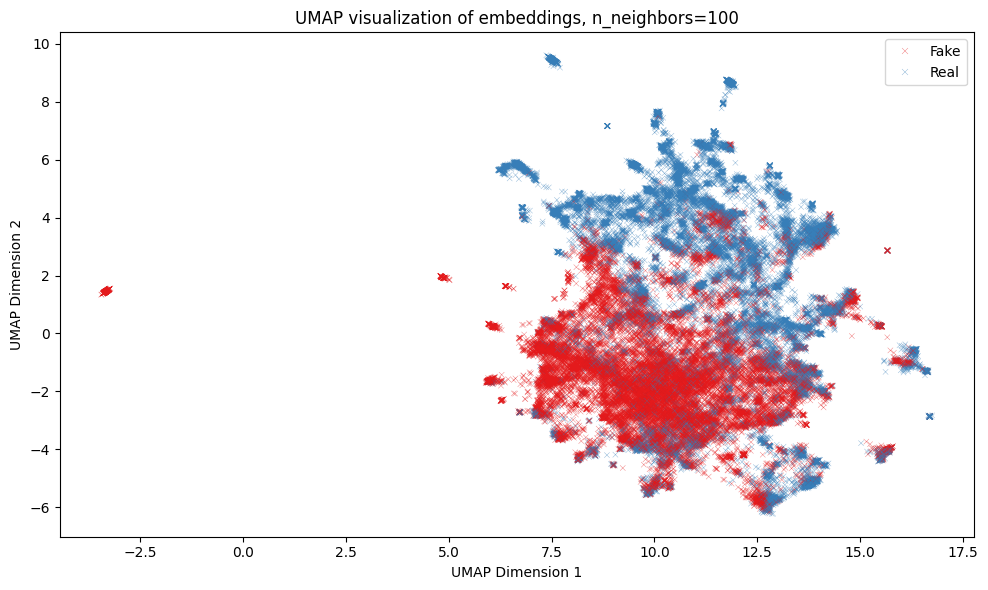

In [121]:
palette_rb = {'Fake': 'red', 'Real': 'blue'}
# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=category_df, x='x', y='y', hue='label', palette='Set1', alpha=0.6, s=15, marker='x')
plt.title("UMAP visualization of embeddings, n_neighbors=100")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.tight_layout()
plt.show()

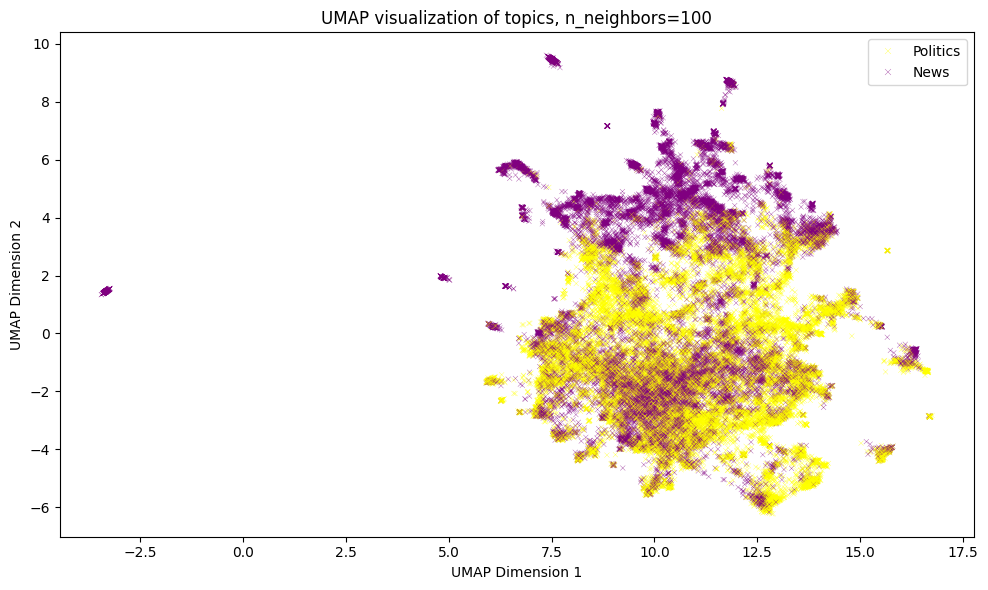

In [126]:
palette_topic = {'Politics': 'yellow', 'News': 'purple'}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=category_df,
    x='x',
    y='y',
    alpha=0.7,
    hue='topic',
    palette=palette_topic,
    marker='x',
    s=13
)

plt.title("UMAP visualization of topics, n_neighbors=100")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

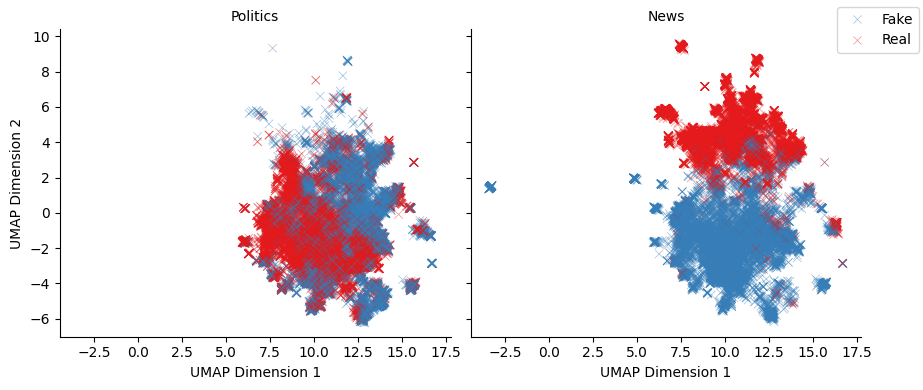

In [129]:
# Definisci la palette: rosso per Fake, blu per Real
palette_rb = {'Fake': 'red', 'Real': 'blue'}

g = sns.FacetGrid(
    category_df,
    col="topic",
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True,
)

g.map_dataframe(
    sns.scatterplot,
    x="x",
    y="y",
    hue="label",
    palette='Set1',
    alpha=0.5,
    marker='x',
    #s=13
)

g.add_legend()
g._legend.set_bbox_to_anchor((1.05, 0.9))
g._legend.set_frame_on(True)


g.set_titles(col_template="{col_name}")
g.set_axis_labels("UMAP Dimension 1", "UMAP Dimension 2")
plt.tight_layout()
plt.show()


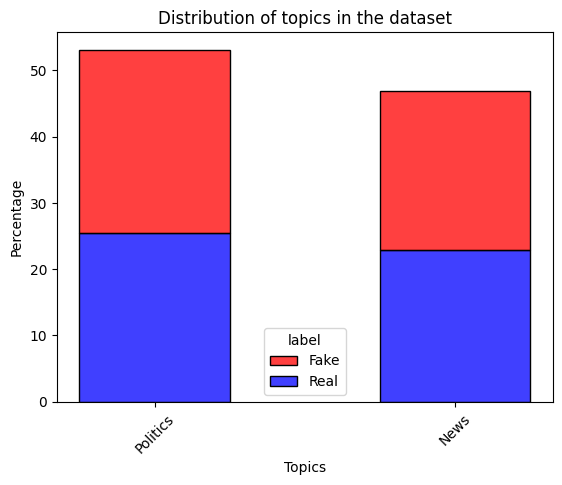

In [ ]:
sns.histplot(data=category_df, x='topic', hue='label', multiple="stack", shrink=0.5, stat="percent", discrete=True, palette=palette_rb)
plt.title("Distribution of topics in the dataset")
plt.xlabel("Topics")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()